In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import sys
import os
import glob
import pandas as pd
import numpy as np
import astropy.units as u
from datetime import date
from random import choices, seed
from math import factorial, erf
from astroquery.simbad import Simbad
import matplotlib.gridspec as gridspec
from scipy.ndimage import gaussian_filter1d
from scipy.stats import norm, uniform, truncnorm
from scipy.special import erfinv, comb
from scipy.special import comb
import h5py
from sklearn.neighbors import KernelDensity
from scipy import stats
from matplotlib.ticker import AutoMinorLocator
from astropy.io import ascii
from IPython.display import clear_output
import time
from scipy.signal import find_peaks


In [2]:
def make_cmap(colors, position, bit=False):
    '''
    make_cmap takes a list of tuples which contain RGB values. The RGB
    values may either be in 8-bit [0 to 255] (in which bit must be set to
    True when called) or arithmetic [0 to 1] (default). make_cmap returns
    a cmap with equally spaced colors.
    Arrange your tuples so that the first color is the lowest value for the
    colorbar and the last is the highest.
    position contains values from 0 to 1 to dictate the location of each color.
    '''
    bit_rgb = np.linspace(0,1,256)
    # if position == None:
    #     position = np.linspace(0,1,len(colors))
    # else:
    if len(position) != len(colors):
        sys.exit("position length must be the same as colors")
    elif position[0] != 0 or position[-1] != 1:
        sys.exit("position must start with 0 and end with 1")
    if bit:
        for i in range(len(colors)):
            colors[i] = (bit_rgb[colors[i][0]],
                         bit_rgb[colors[i][1]],
                         bit_rgb[colors[i][2]])
    cdict = {'red':[], 'green':[], 'blue':[]}
    for pos, color in zip(position, colors):
        cdict['red'].append((pos, color[0], color[0]))
        cdict['green'].append((pos, color[1], color[1]))
        cdict['blue'].append((pos, color[2], color[2]))

    cmap = mpl.colors.LinearSegmentedColormap('my_colormap',cdict,256)
    return cmap
def choose_cmap(custom_cmap, reverse_cmap=False):

    custom_cmaps = {'primordial disks': [(0/255, 26/255, 26/255),
                                         (41/255, 163/255, 163/255),
                                         (179/255, 255/255, 217/255)],
                    'debris disks': [(15/255, 15/255, 62/255),
                                      (102/255, 102/255, 255/255),
                                      (255/255, 204/255, 255/255)],
                    'hot jupiters': [(15/255, 15/255, 62/255),
                                     (102/255, 102/255, 255/255),
                                     (255/255, 250/255, 255/255)],
                    'warm jupiters': [(51/255, 26/255, 0/255),
                                      (255/255, 80/255, 80/255),
                                      (255/255, 255/255, 204/255)],
                    'cyber grape': [(51/255, 0/255, 51/255),
                                    (128/255, 0/255, 128/255),
                                    (153/255, 102/255, 255/255),
                                    (204/255, 255/255, 255/255)],
                    'raspberry punch1': [(51/255, 0/255, 102/255),
                                        (51/255, 204/255, 224/255),
                                        (248/255, 255/255, 230/255)],
                    'raspberry punch2': [(70/255, 0/255, 0/255),
                                        (89/255, 0/255, 179/255),
                                        (51/255, 204/255, 224/255),
                                        (255/255, 255/255, 200/255)],
                    'raspberry punch': [(51/255, 0/255, 102/255),
                                        # (89/255, 0/255, 179/255),
                                        (51/255, 204/255, 224/255),
                                        (255/255, 255/255, 200/255)],
                    }

    chosen_cmap = custom_cmaps[custom_cmap]
    pos_diff = 1./(len(chosen_cmap)-1)
    positions = np.arange(0, 1+pos_diff, pos_diff)
    if reverse_cmap == True:
        chosen_cmap = chosen_cmap[::-1]
    mycolormap = make_cmap(chosen_cmap, position=positions)

    return mycolormap

plt.style.use('/Users/lb8137/Projects/mpl_stylefiles/mystyle.mplstyle')
# plt.rcParams.keys()

Duplicate key in file '/Users/lb8137/Projects/mpl_stylefiles/mystyle.mplstyle', line 40 ('figure.dpi: 150')
Bad value in file '/Users/lb8137/Projects/mpl_stylefiles/mystyle.mplstyle', line 19 ('mathtext.fallback: dejavusans'): Key mathtext.fallback: dejavusans is not a valid fallback font name. Valid fallback font names are cm,stix,stixsans. Passing 'None' will turn fallback off.


In [3]:
tepcat = pd.read_csv("/Users/lb8137/PROJECTS/OBLIQUITY_SYNTHESIS/Tables/Literature_Tables/TEPCAT_Jan2026.csv")
tepcat_lam = tepcat[tepcat['Lambda'] != -999.0]
tepcat_lam = tepcat_lam[tepcat_lam['Teff'] > 0]
tepcat_lam = tepcat_lam[tepcat_lam['Type'] != 'BD']
tepcat_lam = tepcat_lam[tepcat_lam['Type'] != 'CBP']
# tepcat_lam = tepcat_lam[tepcat_lam['M_b'] >= 1.0]
# tepcat = tepcat[tepcat['Teff'] > 6200]

tepcat_Psi = tepcat[tepcat['Psi'] != -999.0]
tepcat_Psi = tepcat_Psi[tepcat_Psi['Teff'] > 0]
# tepcat_Psi = tepcat_Psi[tepcat_Psi['Teff'] < 6200]
tepcat_Psi = tepcat_Psi[tepcat_Psi['Type'] != 'BD']
tepcat_Psi = tepcat_Psi[tepcat_Psi['Type'] != 'CBP']

Albrecht_2022_all = pd.read_csv('/Users/lb8137/PROJECTS/OBLIQUITY_SYNTHESIS/Tables/Literature_Tables/Albrecht_2022_all.csv')


In [4]:
print(tepcat.columns)
print(Albrecht_2022_all.columns)

Index(['System', 'Type', 'RA(deg)', 'Dec(deg)', 'Vmag', 'Kmag', 'length',
       'depth', 'T0(HJDorBJD)', 'T0err', 'Period(day)', 'Perioderr', 'Teff',
       'err', 'err.1', '[Fe/H]', 'erru', 'errd', 'M_A', 'errup', 'errdn',
       'R_A', 'errup.1', 'errdn.1', 'loggA', 'errup.2', 'errdn.2', 'rho_A',
       'errup.3', 'errdn.3', 'e', 'errup.4', 'errdown', 'a(AU)', 'errup.5',
       'errdown.1', 'M_b', 'errup.6', 'errdn.4', 'R_b', 'errup.7', 'errdn.5',
       'g_b', 'errup.8', 'errdn.6', 'rho_b', 'errup.9', 'errdn.7', 'Teq',
       'err.2', 'err.3', 'Lambda', 'err.4', 'err.5', 'Psi', 'err.6', 'err.7'],
      dtype='object')
Index(['Target', 'RA (deg)', 'Dec (deg)', 'lambda', 'lambda +Unc',
       'lambda -Unc', 'istar (deg)', 'istar +Unc', 'istar -Unc', 'Psi (deg)',
       'Psi +Unc', 'Psi -Unc', 'Deltai'],
      dtype='object')


In [5]:
lambdas = []
for lam in tepcat_lam['Lambda'].values:
    lam = abs(lam)
    if lam < 180:
        # lam -= 180
        lambdas.append(lam)


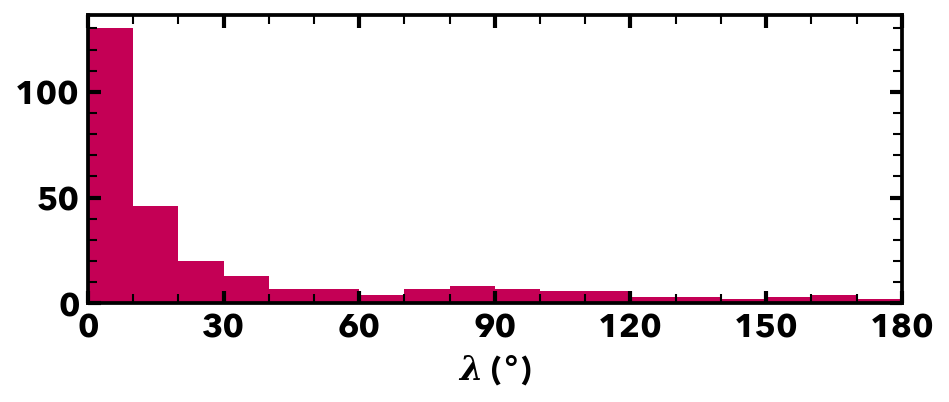

In [6]:
dbin = 10
bins = np.arange(0, 180 + dbin, dbin)

fig = plt.figure(figsize=(7, 2.5), dpi=150)
ax = plt.subplot(111)
ax.minorticks_on()
ax.hist(lambdas, bins=bins, color="#C40055", alpha=1, label='Difference (all)')
# ax.hist(tepcat_Psi['Psi'], bins=bins, color="#C40055", alpha=1, label='Difference (all)')
# ax.hist(Albrecht_2022_all['lambda'], bins=bins, color='#000000', alpha=0.3)
# ax.set_title(r'Transiting Planet Systems', fontsize=16, pad=4)
ax.set_xlabel(r'$\lambda$ ($\degree$)', fontsize=16)
ax.set_xlim(0, max(bins))
ax.tick_params(axis='both', which='major', width=2, length=6)
ax.tick_params(axis='both', which='minor', width=1, length=4.5)
ax.set_xticks(np.arange(0, 180+30, 30))
minor_locator = AutoMinorLocator(3)
ax.xaxis.set_minor_locator(minor_locator)
ax.tick_params(labelsize=16)
# ax.legend(loc='upper right')
plt.show()

6.62088125


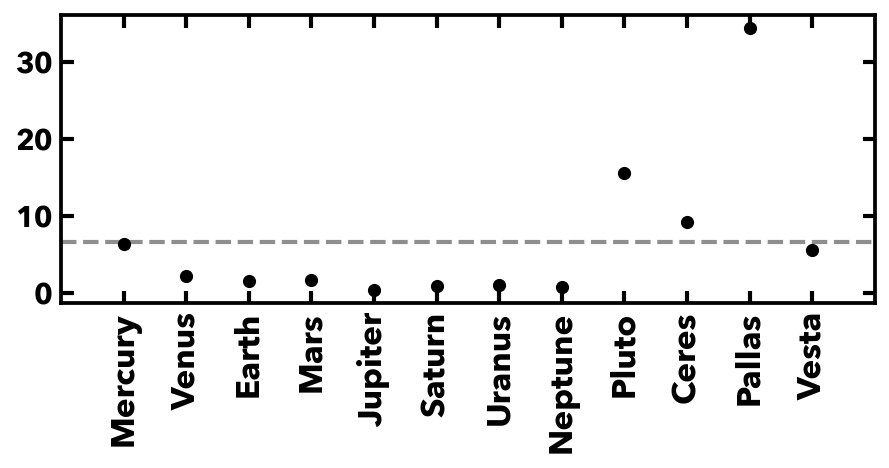

In [ ]:
solar_system_inclinations = {'Sun', 6,
                             'Mercury': 6.34728,
                             'Venus': 2.15454,
                             'Earth': 1.57170,
                             'Mars': 1.63118,
                             'Jupiter': 0.321965,
                             'Saturn': 0.9254,
                             'Uranus': 0.9946,
                             'Neptune': 0.73541,
                             'Pluto': 15.554,
                             'Ceres': 9.1974,
                             'Pallas': 34.43400,
                             'Vesta': 5.5831,
                             }

orbital_inclinations = [incl for incl in solar_system_inclinations.values()]
print(np.mean(orbital_inclinations))

fig = plt.figure(figsize=(7, 2.5), dpi=150)
ax = plt.subplot(111)
ax.minorticks_on()
ax.plot([0, len(solar_system_inclinations)+2], [np.mean(orbital_inclinations), np.mean(orbital_inclinations)], ls='--', color="#8E8E8E", lw=2, zorder=-20)
xticks = []
xticklabels = []
for key_i, key in enumerate(solar_system_inclinations.keys()):
    ax.scatter([key_i+1], [solar_system_inclinations[key]], s=np.pi*3.5**2, color='#000000')
    xticks.append(key_i+1)
    xticklabels.append(key)
ax.set_xlabel('', fontsize=16)
ax.set_xlim(0, len(solar_system_inclinations)+1)
# ax.set_ylim(0, len(solar_system_inclinations)+1)
ax.tick_params(axis='both', which='major', width=2, length=6)
ax.tick_params(axis='both', which='minor', width=1, length=0)
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels, fontsize=16, rotation=90)
plt.show()

In [113]:

# tepcat = tepcat[tepcat['Psi'] != -999.0]
tepcat = tepcat[tepcat['Lambda'] != -999.0]
# tepcat_lambda = tepcat[tepcat['Lambda'] != -999.0]
# tepcat_istar = tepcat[tepcat['Lambda'] != -999.0]
# tepcat_psi = tepcat[tepcat['Psi'] != -999.0]
tepcat = tepcat[tepcat['Teff'] > 0]
# tepcat = tepcat[tepcat['Teff'] > 6200]
tepcat = tepcat[tepcat['Type'] != 'BD']
tepcat = tepcat[tepcat['Type'] != 'CBP']
# tepcat = tepcat[tepcat['Psi'] != -1]
# tepcat = tepcat[tepcat['M_b'] >= 1]
# tepcat = tepcat[tepcat['M_b'] <= 13]
tepcat

done_list = []
retrograde_counts = 0

for system in tepcat['System']:

    if system not in done_list:

        system_dat = tepcat[tepcat['System'] == system]
        system_psi = np.mean(system_dat['Psi'])
        # print(system, system_psi)
        done_list.append(system)

        if system_psi > 90:
            retrograde_counts += 1

regrograde_fraction = retrograde_counts/len(tepcat['System'])

print('\n{:d}/{:d}'.format(retrograde_counts, len(tepcat['System'])))
print('retrograde_fraction', regrograde_fraction)







15/285
retrograde_fraction 0.05263157894736842


In [ ]:
# tepcat = tepcat[tepcat['Lambda'] > 0]
hist_dat = abs(tepcat['Lambda'].values)
hist_dat = hist_dat[hist_dat <= 180]
bins = np.arange(0, 180 + 9, 9)

fig = plt.figure(figsize=(10, 4), dpi=150)
ax = plt.subplot(111)
ax.hist(hist_dat, bins=bins, color='#415858')
ax.plot([90, 90], [0, 120], ls='--', color='#000000', lw=2, alpha=0.30)
ax.set_xlabel(r'$\lambda$ ($\degree$)', fontsize=16)
ax.set_xlim(0, 180)
ax.set_ylim(0, 120)
ax.set_yticks([])
ax.tick_params(labelsize=16)
plt.show()

In [226]:
HJ_results = pd.read_csv('/Users/lib278/Documents/Manuscripts/OBLIQUITY_SYNTHESIS/Tables/Condensed_Sample_By_Date/adopted_highRes_HJ_2024-Dec-04.csv')
WJ_results = pd.read_csv('/Users/lib278/Documents/Manuscripts/OBLIQUITY_SYNTHESIS/Tables/Condensed_Sample_By_Date/adopted_highRes_WJ_2024-Dec-04.csv')
Albrecht_2022 = pd.read_csv('/Users/lib278/Documents/Manuscripts/OBLIQUITY_SYNTHESIS/Tables/Literature_Tables/Albrecht_2022.csv')
Albrecht_2022_all = pd.read_csv('/Users/lib278/Documents/Manuscripts/OBLIQUITY_SYNTHESIS/Tables/Literature_Tables/Albrecht_2022_all.csv')

HJ_results = HJ_results[HJ_results['Target'] != 'WASP-148']
HJ_results = HJ_results[HJ_results['Target'] != 'K2-281']
HJ_results = HJ_results[HJ_results['Target'] != 'Kepler-1654']
WJ_results = WJ_results[WJ_results['Target'] != 'WASP-148']
WJ_results = WJ_results[WJ_results['Target'] != 'K2-281']
WJ_results = WJ_results[WJ_results['Target'] != 'Kepler-1654']

# Albrecht_2022_all = Albrecht_2022_all[Albrecht_2022_all['Psi (deg)'] < 90]

In [230]:
Targets = []
Deltais = []
Deltais_hi = []
Deltais_lo = []
Psis = []
Psis_hi = []
Psis_lo = []


for target_Albrecht in Albrecht_2022['Target']:
    if target_Albrecht in HJ_results['Target'].values:
        Albrecht_row = Albrecht_2022[Albrecht_2022['Target'] == target_Albrecht]
        HJ_row = HJ_results[HJ_results['Target'] == target_Albrecht]

        HJ_Deltai = 90. - np.round(HJ_row['i star (deg)'])
        HJ_Deltai_hi = np.round(HJ_row['i star +Unc'])
        HJ_Deltai_lo = np.round(HJ_row['i star -Unc'])
        HJ_Psi = Albrecht_row['Psi (deg)']
        HJ_Psi_hi = Albrecht_row['Psi +Unc']
        HJ_Psi_lo = Albrecht_row['Psi -Unc']

        if list(HJ_Psi)[0] < 90:
            Targets.append(target_Albrecht)
            Deltais.append(list(HJ_Deltai)[0])
            Deltais_hi.append(list(HJ_Deltai)[0] + list(HJ_Deltai_hi)[0])
            Deltais_lo.append(list(HJ_Deltai)[0] - list(HJ_Deltai_lo)[0])
            Psis.append(list(HJ_Psi)[0])
            Psis_hi.append(list(HJ_Psi)[0] + list(HJ_Psi_hi)[0])
            Psis_lo.append(list(HJ_Psi)[0] - list(HJ_Psi_lo)[0])


for target_Albrecht in Albrecht_2022['Target']:
    if target_Albrecht in WJ_results['Target'].values:
        Albrecht_row = Albrecht_2022[Albrecht_2022['Target'] == target_Albrecht]
        WJ_row = WJ_results[WJ_results['Target'] == target_Albrecht]

        WJ_Deltai = 90. - np.round(WJ_row['i star (deg)'])
        WJ_Deltai_hi = np.round(WJ_row['i star +Unc'])
        WJ_Deltai_lo = np.round(WJ_row['i star -Unc'])
        WJ_Psi = Albrecht_row['Psi (deg)']
        WJ_Psi_hi = Albrecht_row['Psi +Unc']
        WJ_Psi_lo = Albrecht_row['Psi -Unc']

        if list(WJ_Psi)[0] < 90:
            Targets.append(target_Albrecht)
            Deltais.append(list(WJ_Deltai)[0])
            Deltais_hi.append(list(WJ_Deltai)[0] + list(WJ_Deltai_hi)[0])
            Deltais_lo.append(list(WJ_Deltai)[0] - list(WJ_Deltai_lo)[0])
            Psis.append(list(WJ_Psi)[0])
            Psis_hi.append(list(WJ_Psi)[0] + list(WJ_Psi_hi)[0])
            Psis_lo.append(list(WJ_Psi)[0] - list(WJ_Psi_lo)[0])


Psi_difference = abs(np.array(Psis) - np.array(Deltais))
Psi_difference_hi = abs(np.array(Psis_hi) - np.array(Deltais_lo))
Psi_difference_lo = abs(np.array(Psis_lo) - np.array(Deltais_hi))

for bep in range(len(Psi_difference)):
    print(Targets[bep], Psi_difference[bep])
print('\nMean: ', np.mean(Psi_difference))
print('\nMedian: ', np.median(Psi_difference))



Deltais_all = 90. - np.array(Albrecht_2022_all['istar (deg)'])
Psis_all = np.array(Albrecht_2022_all['Psi (deg)'])
Psi_difference_all = abs(np.array(Psis_all) - np.array(Deltais_all))

len(Psi_difference_all)

CoRoT-2 8.9
HATS-2 4.399999999999999
HD 209458 0.8000000000000007
Qatar-1 16.9
Qatar 2 11.4
WASP-4 20.0
WASP-5 4.199999999999999
WASP-6 12.9
WASP-19 3.7
WASP-32 0.20000000000000284
WASP-41 5.399999999999999
WASP-43 12.7
WASP-52 2.8
WASP-69 3.8
V1298 Tau 8.0
Kepler-9 15.899999999999999
WASP-84 0.3999999999999986

Mean:  7.788235294117648

Median:  5.399999999999999


62

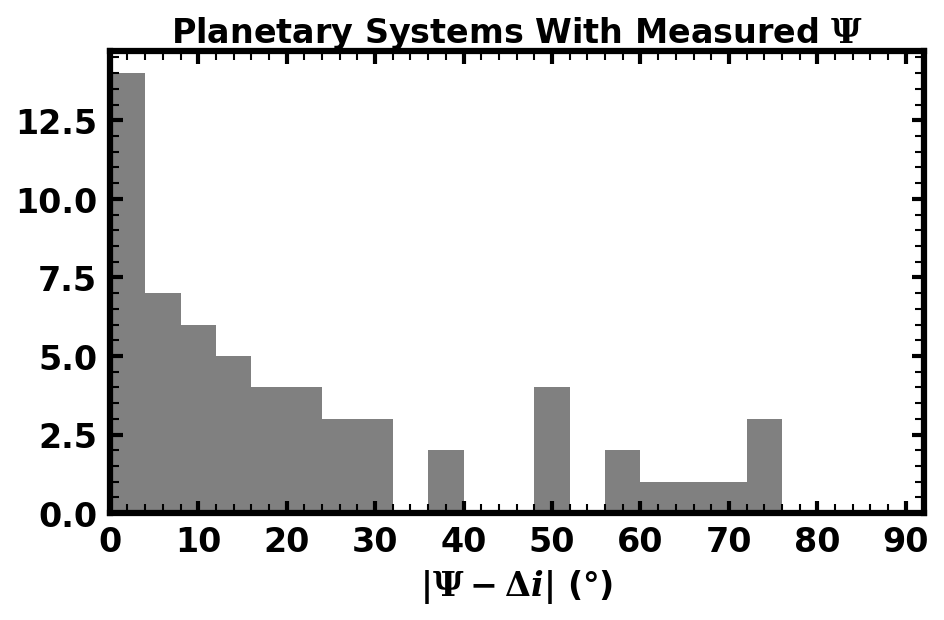


Mean:  25.641935483870963
Stddev:  29.659806375384136

Median:  14.200000000000003


 23 / 62
0.3709677419354839


In [246]:

dbin = 4
bins = np.arange(0, 90 + dbin, dbin)

fig = plt.figure(figsize=(7, 4), dpi=150)
ax = plt.subplot(111)
ax.minorticks_on()
ax.hist(Psi_difference_all, bins=bins, color='grey', alpha=1, label='Difference (all)')
# ax.plot([90, 90], [0, max(bins)], ls='--', color='#000000', lw=2, alpha=0.30)
ax.set_title(r'Planetary Systems With Measured $\Psi$', fontsize=16, pad=4)
ax.set_xlabel(r'$|\Psi - \Delta i|$ ($\degree$)', fontsize=16)
ax.set_xlim(0, max(bins))
ax.tick_params(axis='both', which='major', width=2, length=6)
ax.tick_params(axis='both', which='minor', width=1, length=4.5)
ax.set_xticks(np.arange(0, 90 + 10, 10))
# ax.set_xticklabels(['0', ' ', '10', ' ', '20', ' ', '40', ' ', '50', ' ', '60', ' ', '70', ' ', '80', ' ', '90'])
ax.tick_params(labelsize=16)
# ax.legend(loc='upper right')
plt.show()




print('\nMean: ', np.mean(Psi_difference_all))
print('Stddev: ', np.std(Psi_difference_all, ddof=1))
print('\nMedian: ', np.median(Psi_difference_all))

print('\n\n', len(Psi_difference_all[Psi_difference_all < 10]), '/', len(Psi_difference_all))
print(len(Psi_difference_all[Psi_difference_all < 10])/len(Psi_difference_all))


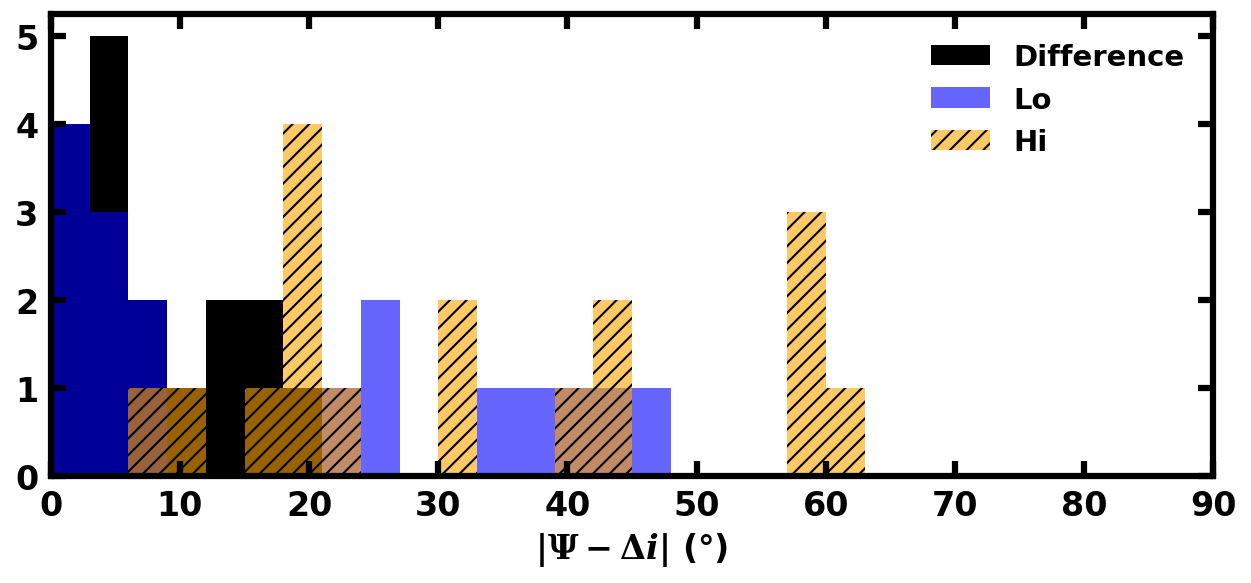

In [151]:
# tepcat = tepcat[tepcat['Lambda'] > 0]

dbin = 3
bins = np.arange(0, 90 + dbin, dbin)

fig = plt.figure(figsize=(10, 4), dpi=150)
ax = plt.subplot(111)
ax.hist(Psi_difference, bins=bins, color='black', alpha=1, label='Difference')
ax.hist(Psi_difference_lo, bins=bins, color='blue', alpha=0.6, label='Lo')
ax.hist(Psi_difference_hi, bins=bins, color='orange', hatch='///', alpha=0.6, label='Hi')
# ax.plot([90, 90], [0, max(bins)], ls='--', color='#000000', lw=2, alpha=0.30)
ax.set_xlabel(r'$|\Psi - \Delta i|$ ($\degree$)', fontsize=16)
ax.set_xlim(0, max(bins))
# ax.set_ylim(0, 120)
# ax.set_yticks([])
ax.tick_params(labelsize=16)
ax.legend(loc='upper right')
plt.show()

In [153]:
Deltais

[0.0,
 25.0,
 29.0,
 0.0,
 0.0,
 0.0,
 18.0,
 26.0,
 0.0,
 36.0,
 28.0,
 0.0,
 0.0,
 0.0,
 0.0,
 44.0,
 19.0]

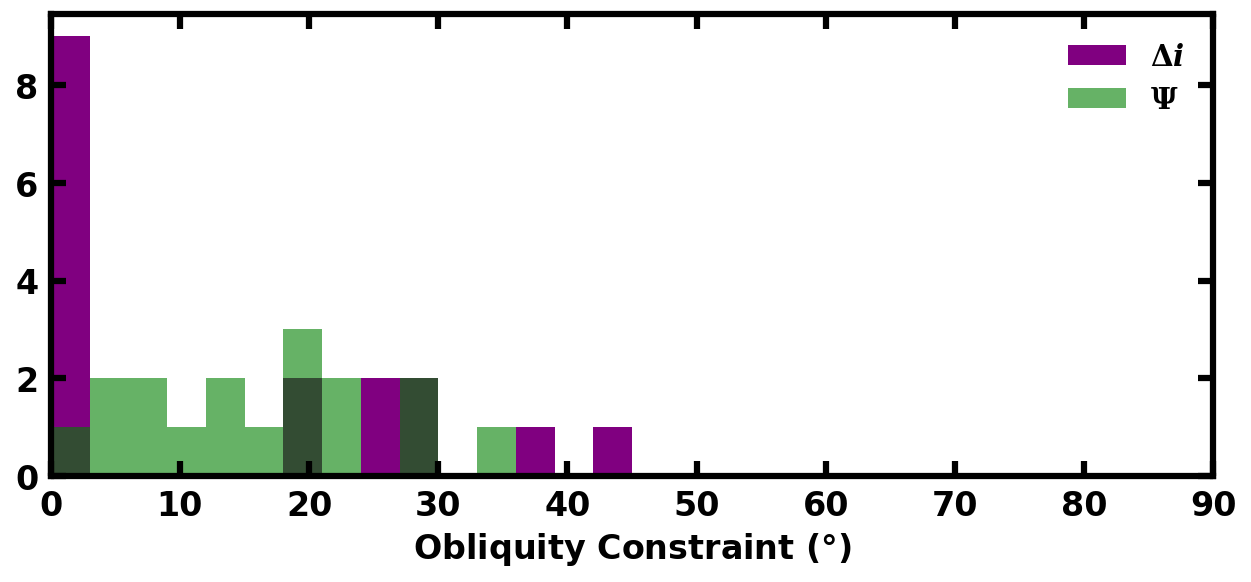

In [154]:
# tepcat = tepcat[tepcat['Lambda'] > 0]

dbin = 3
bins = np.arange(0, 90 + dbin, dbin)

fig = plt.figure(figsize=(10, 4), dpi=150)
ax = plt.subplot(111)
ax.hist(Deltais, bins=bins, color='purple', alpha=1, label=r'$\Delta i$')
ax.hist(Psis, bins=bins, color='green', alpha=0.6, label=r'$\Psi$')
# ax.plot([90, 90], [0, max(bins)], ls='--', color='#000000', lw=2, alpha=0.30)
ax.set_xlabel(r'Obliquity Constraint ($\degree$)', fontsize=16)
ax.set_xlim(0, max(bins))
# ax.set_ylim(0, 120)
# ax.set_yticks([])
ax.tick_params(labelsize=16)
ax.legend(loc='upper right')
plt.show()